### Question 1


In [22]:
import os
import warnings
warnings.filterwarnings("ignore")



import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import (
    LinearDiscriminantAnalysis,
    QuadraticDiscriminantAnalysis
)


# ============================================================
# 0. Basic configuration
# ============================================================

PATH_X_TR = "./DD/X_TR.csv"
PATH_y_TR = "./DD/Y_TR.csv"



OUTPUT_DIR = "q1a_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

RANDOM_STATE = 42


# sample size 最好选择 7 的倍数，方便 balanced sampling


#SAMPLE_SIZES = [140, 350, 700, 1400, 2800, 5600]

SAMPLE_SIZES = [140, 350, 700, 1400, 2800, 5600]
SAMPLE_SIZES = [5600,2800,1400,700,350,140]
print("SAMPLE SIZES ", SAMPLE_SIZES)

# 太慢了 调整为3
REPEATS = 3

TEST_SIZE = 0.30

# Cross-validation folds inside training set
CV_FOLDS = 4

# Feature selection 数量
# 保留特征数量的设置
FEATURE_K_OPTIONS = [50, 100, 200, 400]

# PCA 保留方差比例
PCA_OPTIONS = [0.80, 0.90, 0.95]


SAMPLE SIZES  [5600, 2800, 1400, 700, 350, 140]


In [23]:

# ============================================================
# 1. Load data
# ============================================================

def load_data(path_x, path_y):
    """
    Read X and y from csv files.
    This function is written to handle common label-file problems.
    """

    X = pd.read_csv(path_x, index_col=0)

    y_df = pd.read_csv(path_y)

    print("Raw X shape:", X.shape)
    print("Raw y shape:", y_df.shape)
    print("Raw y columns:", y_df.columns.tolist())

    # Case 1: y file has only one column
    if y_df.shape[1] == 1:
        y = y_df.iloc[:, 0]

    # Case 2: y file has two columns, first column is probably index
    elif y_df.shape[1] == 2:
        y = y_df.iloc[:, 1]

    else:
        raise ValueError(
            "y file has more than 2 columns. Please inspect y_TR.csv manually."
        )

    y = pd.Series(y).reset_index(drop=True)
    X = X.reset_index(drop=True)

    print("\nAfter processing:")
    print("X shape:", X.shape)
    print("y shape:", y.shape)
    print("Number of classes:", y.nunique())
    print("\nClass distribution:")
    print(y.value_counts().sort_index())

    return X, y


X_TR, y_TR = load_data(PATH_X_TR, PATH_y_TR)

N_FEATURES = X_TR.shape[1]
N_CLASSES = y_TR.nunique()

print("\nNumber of features:", N_FEATURES)
print("Number of classes:", N_CLASSES)


Raw X shape: (8080, 819)
Raw y shape: (8080, 1)
Raw y columns: ['class']

After processing:
X shape: (8080, 819)
y shape: (8080,)
Number of classes: 7

Class distribution:
class
1    1071
2    1308
3    1214
4     489
5    1164
6    1204
7    1630
Name: count, dtype: int64

Number of features: 819
Number of classes: 7


In [24]:

# ============================================================
# 2. Balanced sampling
# ============================================================

def balanced_sample(X, y, n_total, random_state=0):
    """
    Draw approximately balanced sample from all classes.
    If n_total is larger than available data, use all data.
    """

    rng = np.random.default_rng(random_state)

    X = pd.DataFrame(X).reset_index(drop=True)
    y = pd.Series(y).reset_index(drop=True)

    classes = np.sort(y.unique())
    n_classes = len(classes)

    n_per_class = n_total // n_classes

    selected_indices = []

    for c in classes:
        idx_c = np.where(y == c)[0]
        n_c = min(n_per_class, len(idx_c))

        chosen = rng.choice(idx_c, size=n_c, replace=False)
        selected_indices.extend(chosen)

    selected_indices = np.array(selected_indices)
    rng.shuffle(selected_indices)

    X_sub = X.iloc[selected_indices].reset_index(drop=True)
    y_sub = y.iloc[selected_indices].reset_index(drop=True)

    return X_sub, y_sub


In [25]:

# ============================================================
# 3. Define pipelines
# ============================================================

def make_pipelines():
    """
    All models use:
    StandardScaler -> SelectKBest -> PCA -> Classifier

    This ensures:
    1. feature selection happens only inside training data
    2. PCA happens only inside training data
    3. no data leakage occurs
    """

    pipelines = {}



    # --------------------------------------------------------
    # L1 sparse logistic regression
    # --------------------------------------------------------
    pipelines["FS_PCA_L1_Logistic"] = Pipeline([
        ("scaler", StandardScaler()),
        ("select", SelectKBest(score_func=f_classif)),
        ("pca", PCA()),
        ("clf", LogisticRegression(
            penalty="l1",
            solver="saga",
            max_iter=5000,
            class_weight="balanced"
        ))
    ])

    # --------------------------------------------------------
    # Shrinkage LDA
    # --------------------------------------------------------
    pipelines["FS_PCA_Shrinkage_LDA"] = Pipeline([
        ("scaler", StandardScaler()),
        ("select", SelectKBest(score_func=f_classif)),
        ("pca", PCA()),
        ("clf", LinearDiscriminantAnalysis(
            solver="lsqr",
            shrinkage="auto"
        ))
    ])




    # --------------------------------------------------------
    # RBF SVM
    # --------------------------------------------------------
    pipelines["FS_PCA_RBF_SVM"] = Pipeline([
        ("scaler", StandardScaler()),
        ("select", SelectKBest(score_func=f_classif)),
        ("pca", PCA()),
        ("clf", SVC(
            kernel="rbf",
            probability=True,
            class_weight="balanced"
        ))
    ])

    # --------------------------------------------------------
    # Random Forest
    # Random Forest normally does not need scaling or PCA,
    # but here we still include feature selection + PCA
    # to keep the pipeline comparable.
    # --------------------------------------------------------
    pipelines["FS_PCA_RandomForest"] = Pipeline([
        ("scaler", StandardScaler()),
        ("select", SelectKBest(score_func=f_classif)),
        ("pca", PCA()),
        ("clf", RandomForestClassifier(
            n_estimators=300,
            max_features="sqrt",
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ])

    return pipelines


pipelines = make_pipelines()


In [26]:

# ============================================================
# 4. Define parameter grids for inner cross-validation
# ============================================================

def make_param_grids():
    """
    Parameter grids are deliberately not too large,
    otherwise the experiment can become very slow.
    """

    common_fs_pca = {
        "select__k": FEATURE_K_OPTIONS,
        "pca__n_components": PCA_OPTIONS
    }

    param_grids = {}


    param_grids["FS_PCA_L1_Logistic"] = {
        **common_fs_pca,
        "clf__C": [0.05, 0.1, 0.5, 1]
    }

    param_grids["FS_PCA_Shrinkage_LDA"] = {
        **common_fs_pca
    }





    param_grids["FS_PCA_RBF_SVM"] = {
        **common_fs_pca,
        "clf__C": [0.1, 1, 10],
        "clf__gamma": ["scale", 0.01, 0.001]
    }

    param_grids["FS_PCA_RandomForest"] = {
        **common_fs_pca,
        "clf__max_depth": [None, 5, 10, 20],
        "clf__min_samples_leaf": [1, 2, 5]
    }

    return param_grids


param_grids = make_param_grids()


In [27]:

# ============================================================
# 5. Helper functions
# ============================================================

def adjust_param_grid_for_sample_size(param_grid, X_train):
    """
    SelectKBest k cannot be larger than number of features.
    Also, PCA n_components as float is okay.
    """

    adjusted_grid = param_grid.copy()

    if "select__k" in adjusted_grid:
        valid_k = [k for k in adjusted_grid["select__k"] if k <= X_train.shape[1]]

        if len(valid_k) == 0:
            valid_k = [min(50, X_train.shape[1])]

        adjusted_grid["select__k"] = valid_k

    return adjusted_grid


def fit_with_inner_cv(model, param_grid, X_train, y_train):
    """
    Fit model using inner cross-validation.
    """

    cv = StratifiedKFold(
        n_splits=CV_FOLDS,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        scoring="f1_macro",
        cv=cv,
        n_jobs=-1,
        refit=True,
        error_score=np.nan
    )

    grid.fit(X_train, y_train)

    return grid.best_estimator_, grid.best_params_, grid.best_score_


def extract_selected_feature_count(fitted_pipeline):
    """
    Count how many original features were kept by SelectKBest.
    """

    if "select" not in fitted_pipeline.named_steps:
        return np.nan

    selector = fitted_pipeline.named_steps["select"]
    selected_mask = selector.get_support()

    return int(np.sum(selected_mask))


def extract_selected_feature_indices(fitted_pipeline):
    """
    Return selected original feature indices.
    """

    if "select" not in fitted_pipeline.named_steps:
        return []

    selector = fitted_pipeline.named_steps["select"]
    selected_idx = np.where(selector.get_support())[0]

    return selected_idx.tolist()


def extract_pca_components_count(fitted_pipeline):
    """
    Count number of PCA components used after fitting.
    """

    if "pca" not in fitted_pipeline.named_steps:
        return np.nan

    pca = fitted_pipeline.named_steps["pca"]

    if hasattr(pca, "n_components_"):
        return int(pca.n_components_)

    return np.nan


def evaluate_model(model, X_test, y_test):
    """
    Compute overall and class-specific metrics.
    """

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")

    report = classification_report(
        y_test,
        y_pred,
        output_dict=True,
        zero_division=0
    )

    cm = confusion_matrix(y_test, y_pred)

    return acc, macro_f1, report, cm, y_pred


In [28]:

# ============================================================
# 6. Main experiment: sample size effect
# ============================================================


## 这是模型训练的主要流程

all_results = []
all_class_reports = []
all_confusion_matrices = {}
all_best_params = []
all_selected_features = {}

for sample_size in SAMPLE_SIZES:

    print("\n" + "=" * 70)
    print(f"Sample size: {sample_size}")
    print("=" * 70)

    for repeat in range(REPEATS):

        print(f"\nRepeat {repeat + 1}/{REPEATS}")

        # ----------------------------------------------------
        # Balanced subsampling
        # ----------------------------------------------------
        X_sub, y_sub = balanced_sample(
            X_TR,
            y_TR,
            n_total=sample_size,
            random_state=1000 * sample_size + repeat
        )

        # ----------------------------------------------------
        # Train/test split
        # ----------------------------------------------------
        X_train, X_test, y_train, y_test = train_test_split(
            X_sub,
            y_sub,
            test_size=TEST_SIZE,
            stratify=y_sub,
            random_state=repeat
        )

        for model_name, pipeline in pipelines.items():

            print(f"  Fitting {model_name}...")

            model = clone(pipeline)

            param_grid = adjust_param_grid_for_sample_size(
                param_grids[model_name],
                X_train
            )

            try:
                best_model, best_params, cv_score = fit_with_inner_cv(
                    model,
                    param_grid,
                    X_train,
                    y_train
                )

                acc, macro_f1, report, cm, y_pred = evaluate_model(
                    best_model,
                    X_test,
                    y_test
                )

                selected_count = extract_selected_feature_count(best_model)
                selected_idx = extract_selected_feature_indices(best_model)
                pca_count = extract_pca_components_count(best_model)

                all_results.append({
                    "sample_size": sample_size,
                    "repeat": repeat,
                    "model": model_name,
                    "accuracy": acc,
                    "macro_f1": macro_f1,
                    "inner_cv_macro_f1": cv_score,
                    "selected_feature_count": selected_count,
                    "pca_component_count": pca_count
                })

                all_best_params.append({
                    "sample_size": sample_size,
                    "repeat": repeat,
                    "model": model_name,
                    "best_params": best_params
                })

                all_confusion_matrices[(sample_size, repeat, model_name)] = cm
                all_selected_features[(sample_size, repeat, model_name)] = selected_idx

                # class-specific report
                for cls in sorted(y_TR.unique()):
                    cls_str = str(cls)

                    if cls_str in report:
                        all_class_reports.append({
                            "sample_size": sample_size,
                            "repeat": repeat,
                            "model": model_name,
                            "class": cls,
                            "precision": report[cls_str]["precision"],
                            "recall": report[cls_str]["recall"],
                            "f1_score": report[cls_str]["f1-score"],
                            "support": report[cls_str]["support"]
                        })

                print(
                    f"    acc={acc:.4f}, macro_f1={macro_f1:.4f}, "
                    f"selected={selected_count}, pca={pca_count}"
                )

            except Exception as e:
                print(f"    Failed: {model_name}, error: {e}")

                all_results.append({
                    "sample_size": sample_size,
                    "repeat": repeat,
                    "model": model_name,
                    "accuracy": np.nan,
                    "macro_f1": np.nan,
                    "inner_cv_macro_f1": np.nan,
                    "selected_feature_count": np.nan,
                    "pca_component_count": np.nan
                })



Sample size: 5600

Repeat 1/5
  Fitting FS_PCA_L1_Logistic...
    acc=0.9313, macro_f1=0.9331, selected=50, pca=43
  Fitting FS_PCA_Shrinkage_LDA...
    acc=0.9175, macro_f1=0.9198, selected=50, pca=43
  Fitting FS_PCA_RBF_SVM...
    acc=0.9427, macro_f1=0.9441, selected=50, pca=43
  Fitting FS_PCA_RandomForest...
    acc=0.9250, macro_f1=0.9257, selected=50, pca=43

Repeat 2/5
  Fitting FS_PCA_L1_Logistic...
    acc=0.9364, macro_f1=0.9385, selected=50, pca=43
  Fitting FS_PCA_Shrinkage_LDA...
    acc=0.9288, macro_f1=0.9311, selected=50, pca=43
  Fitting FS_PCA_RBF_SVM...


KeyboardInterrupt: 

In [42]:

# ============================================================
# 7. Save raw results
# ============================================================

results_df = pd.DataFrame(all_results)
class_reports_df = pd.DataFrame(all_class_reports)
best_params_df = pd.DataFrame(all_best_params)

results_path = os.path.join(OUTPUT_DIR, "q1a_results_all.csv")
class_reports_path = os.path.join(OUTPUT_DIR, "q1a_class_reports_all.csv")
best_params_path = os.path.join(OUTPUT_DIR, "q1a_best_params.csv")

results_df.to_csv(results_path, index=False)
class_reports_df.to_csv(class_reports_path, index=False)
best_params_df.to_csv(best_params_path, index=False)

print("\nSaved:")
print(results_path)
print(class_reports_path)
print(best_params_path)



Saved:
q1a_results\q1a_results_all.csv
q1a_results\q1a_class_reports_all.csv
q1a_results\q1a_best_params.csv


In [43]:

# ============================================================
# 8. Summarize overall performance
# ============================================================

summary = results_df.groupby(["sample_size", "model"]).agg(
    accuracy_mean=("accuracy", "mean"),
    accuracy_std=("accuracy", "std"),
    macro_f1_mean=("macro_f1", "mean"),
    macro_f1_std=("macro_f1", "std"),
    inner_cv_macro_f1_mean=("inner_cv_macro_f1", "mean"),
    selected_feature_count_mean=("selected_feature_count", "mean"),
    pca_component_count_mean=("pca_component_count", "mean")
).reset_index()

summary_path = os.path.join(OUTPUT_DIR, "q1a_summary.csv")
summary.to_csv(summary_path, index=False)

print("\nOverall summary:")
print(summary)

print("\nSaved:")
print(summary_path)



Overall summary:
    sample_size                   model  accuracy_mean  accuracy_std  \
0           140      FS_PCA_L1_Logistic       0.654762      0.088020   
1           140      FS_PCA_L2_Logistic       0.672619      0.052794   
2           140       FS_PCA_Linear_SVM       0.666667      0.093233   
3           140          FS_PCA_RBF_SVM       0.678571      0.062994   
4           140     FS_PCA_RandomForest       0.696429      0.022796   
5           140  FS_PCA_Regularized_QDA       0.571429      0.033672   
6           140    FS_PCA_Shrinkage_LDA       0.761905      0.027493   
7           350      FS_PCA_L1_Logistic       0.780952      0.044671   
8           350      FS_PCA_L2_Logistic       0.776190      0.053026   
9           350       FS_PCA_Linear_SVM       0.795238      0.022671   
10          350          FS_PCA_RBF_SVM       0.830952      0.048171   
11          350     FS_PCA_RandomForest       0.804762      0.029611   
12          350  FS_PCA_Regularized_QDA       

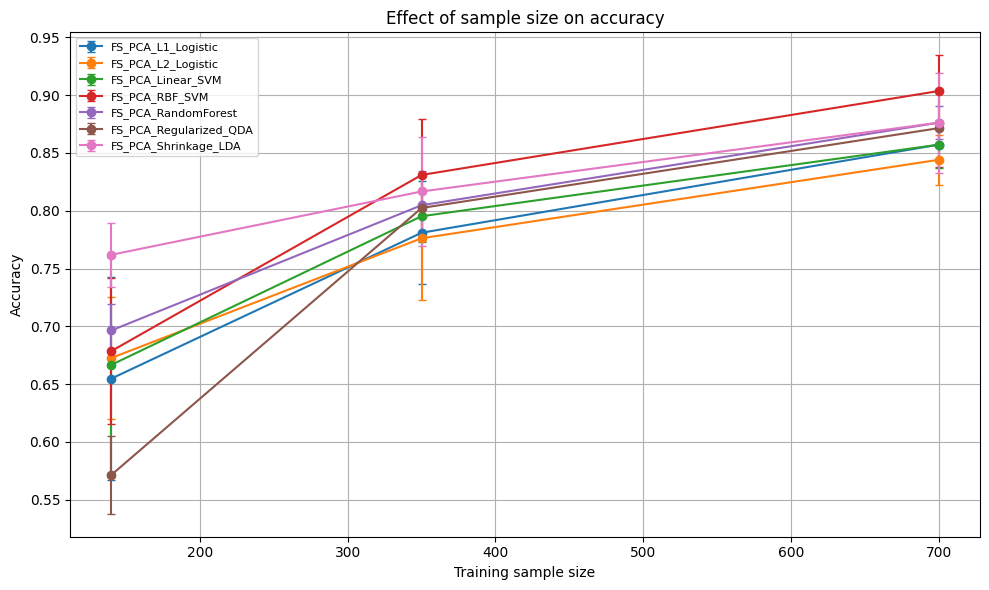

Saved: q1a_results\plot_sample_size_accuracy.png


In [44]:

# ============================================================
# 9. Plot: sample size vs accuracy
# ============================================================

plt.figure(figsize=(10, 6))

for model_name in summary["model"].unique():
    tmp = summary[summary["model"] == model_name]

    plt.errorbar(
        tmp["sample_size"],
        tmp["accuracy_mean"],
        yerr=tmp["accuracy_std"],
        marker="o",
        capsize=3,
        label=model_name
    )

plt.xlabel("Training sample size")
plt.ylabel("Accuracy")
plt.title("Effect of sample size on accuracy")
plt.legend(fontsize=8)
plt.grid(True)
plt.tight_layout()

fig_path = os.path.join(OUTPUT_DIR, "plot_sample_size_accuracy.png")
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved:", fig_path)


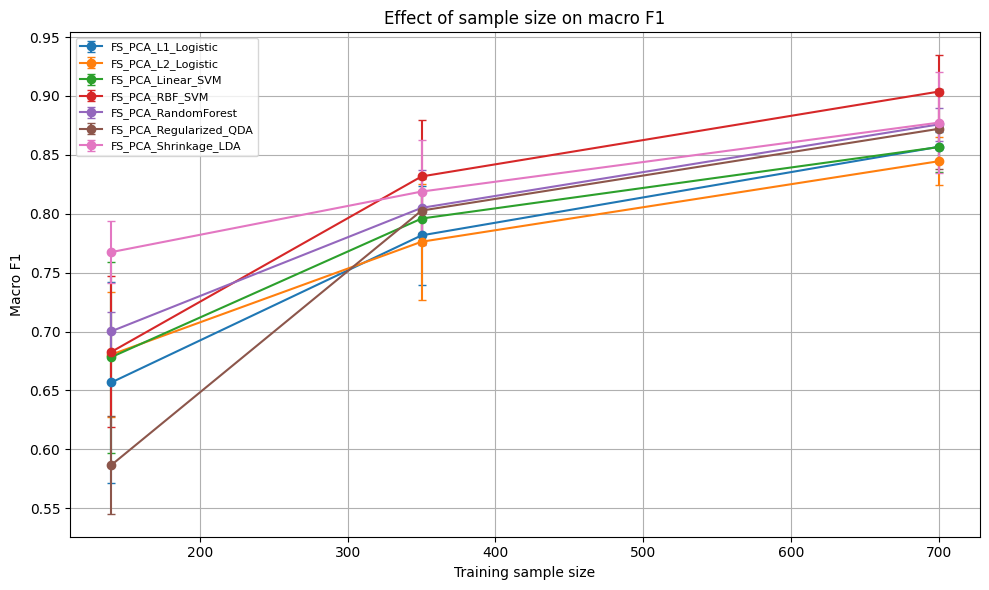

Saved: q1a_results\plot_sample_size_macro_f1.png


In [45]:

# ============================================================
# 10. Plot: sample size vs macro F1
# ============================================================

plt.figure(figsize=(10, 6))

for model_name in summary["model"].unique():
    tmp = summary[summary["model"] == model_name]

    plt.errorbar(
        tmp["sample_size"],
        tmp["macro_f1_mean"],
        yerr=tmp["macro_f1_std"],
        marker="o",
        capsize=3,
        label=model_name
    )

plt.xlabel("Training sample size")
plt.ylabel("Macro F1")
plt.title("Effect of sample size on macro F1")
plt.legend(fontsize=8)
plt.grid(True)
plt.tight_layout()

fig_path = os.path.join(OUTPUT_DIR, "plot_sample_size_macro_f1.png")
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved:", fig_path)


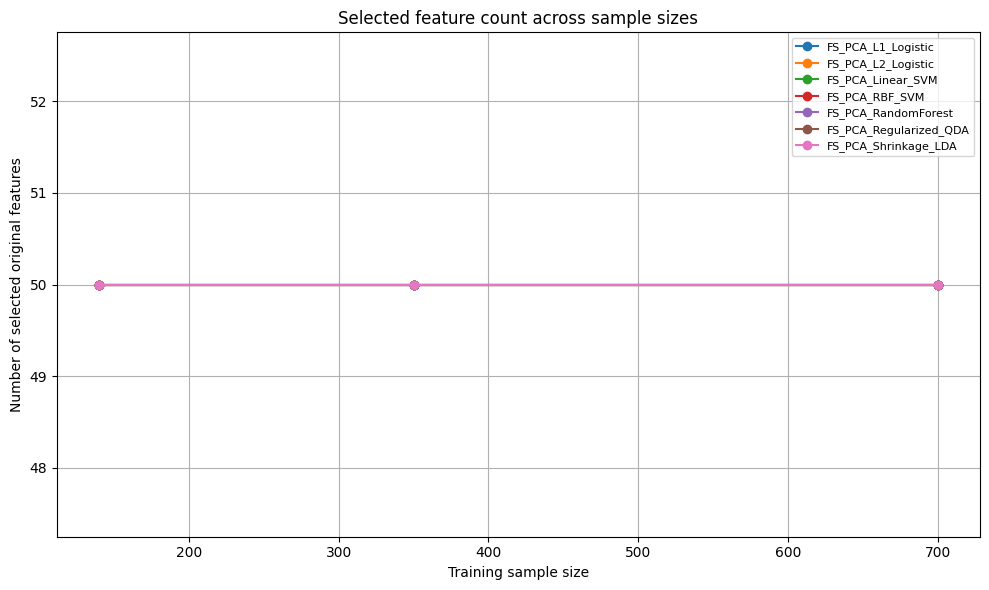

Saved: q1a_results\plot_selected_feature_count.png


In [46]:

# ============================================================
# 11. Plot: selected feature count
# ============================================================

plt.figure(figsize=(10, 6))

for model_name in summary["model"].unique():
    tmp = summary[summary["model"] == model_name]

    plt.plot(
        tmp["sample_size"],
        tmp["selected_feature_count_mean"],
        marker="o",
        label=model_name
    )

plt.xlabel("Training sample size")
plt.ylabel("Number of selected original features")
plt.title("Selected feature count across sample sizes")
plt.legend(fontsize=8)
plt.grid(True)
plt.tight_layout()

fig_path = os.path.join(OUTPUT_DIR, "plot_selected_feature_count.png")
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved:", fig_path)


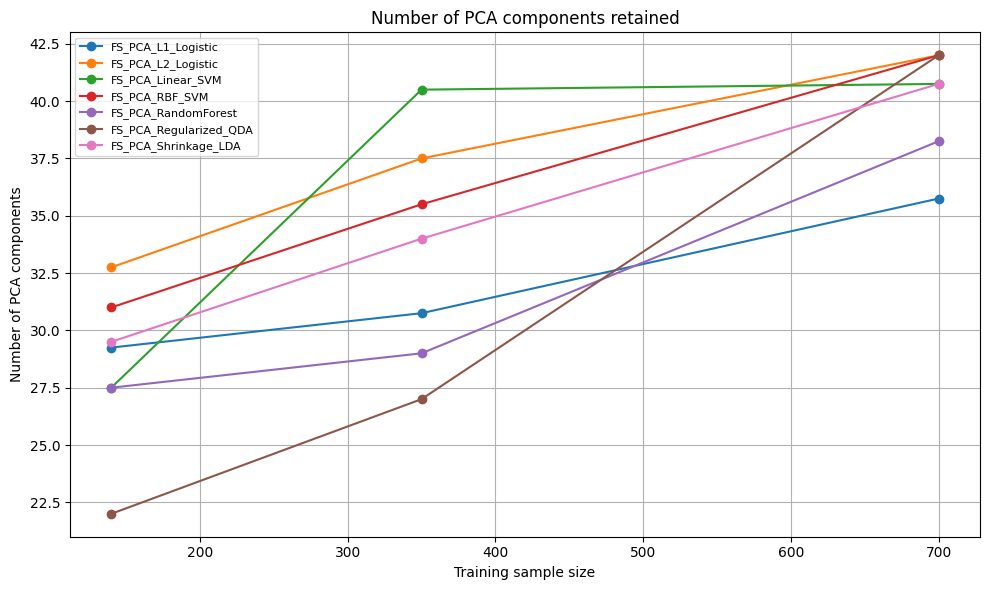

Saved: q1a_results\plot_pca_component_count.png


In [47]:

# ============================================================
# 12. Plot: PCA component count
# ============================================================

plt.figure(figsize=(10, 6))

for model_name in summary["model"].unique():
    tmp = summary[summary["model"] == model_name]

    plt.plot(
        tmp["sample_size"],
        tmp["pca_component_count_mean"],
        marker="o",
        label=model_name
    )

plt.xlabel("Training sample size")
plt.ylabel("Number of PCA components")
plt.title("Number of PCA components retained")
plt.legend(fontsize=8)
plt.grid(True)
plt.tight_layout()

fig_path = os.path.join(OUTPUT_DIR, "plot_pca_component_count.png")
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved:", fig_path)


In [48]:

# ============================================================
# 13. Class-specific performance summary
# ============================================================

class_summary = class_reports_df.groupby(
    ["sample_size", "model", "class"]
).agg(
    precision_mean=("precision", "mean"),
    recall_mean=("recall", "mean"),
    f1_mean=("f1_score", "mean"),
    f1_std=("f1_score", "std"),
    support_mean=("support", "mean")
).reset_index()

class_summary_path = os.path.join(OUTPUT_DIR, "q1a_class_summary.csv")
class_summary.to_csv(class_summary_path, index=False)

print("\nClass-specific summary:")
print(class_summary.head())

print("\nSaved:")
print(class_summary_path)



Class-specific summary:
   sample_size               model  class  precision_mean  recall_mean  \
0          140  FS_PCA_L1_Logistic      1        0.617857     0.666667   
1          140  FS_PCA_L1_Logistic      2        0.766667     0.541667   
2          140  FS_PCA_L1_Logistic      3        0.475000     0.458333   
3          140  FS_PCA_L1_Logistic      4        0.886905     0.791667   
4          140  FS_PCA_L1_Logistic      5        0.908333     0.833333   

    f1_mean    f1_std  support_mean  
0  0.623164  0.159988           6.0  
1  0.629293  0.265939           6.0  
2  0.460140  0.111104           6.0  
3  0.827914  0.060116           6.0  
4  0.867424  0.115639           6.0  

Saved:
q1a_results\q1a_class_summary.csv


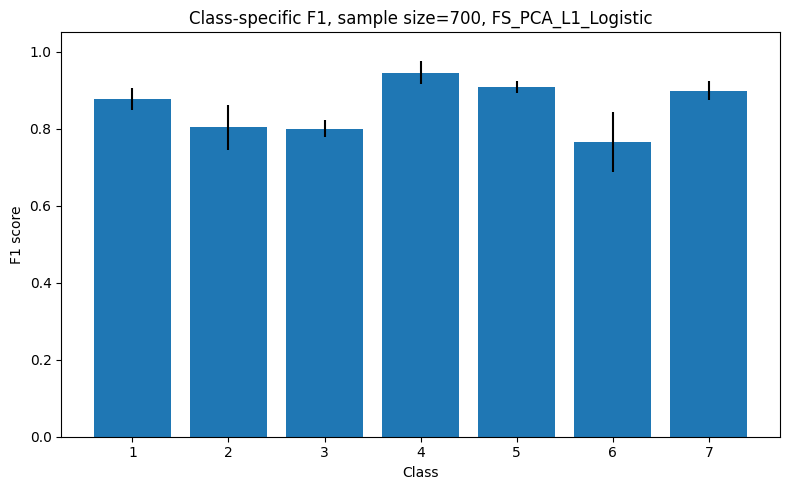

Saved: q1a_results\plot_class_f1_FS_PCA_L1_Logistic_n700.png


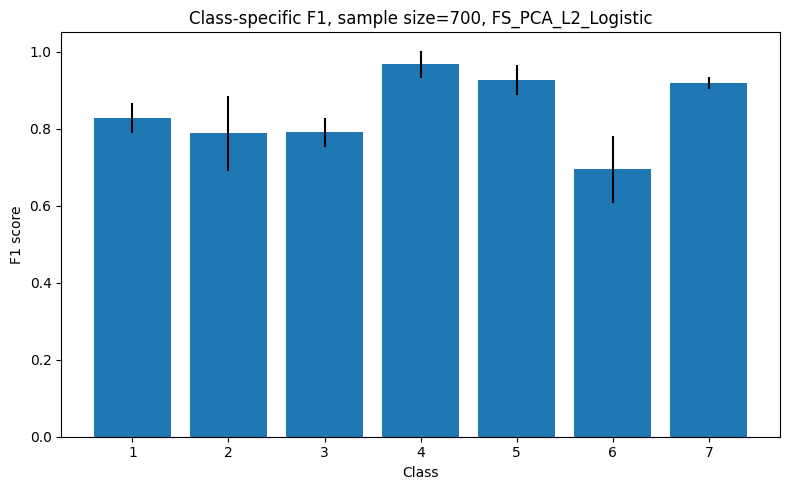

Saved: q1a_results\plot_class_f1_FS_PCA_L2_Logistic_n700.png


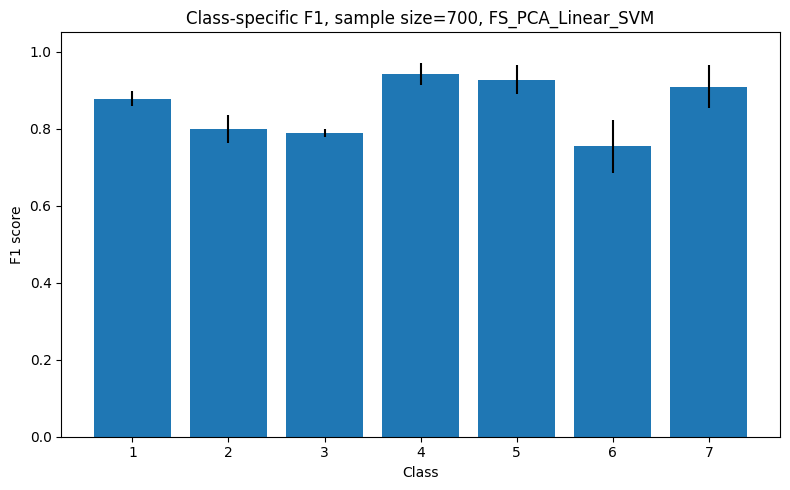

Saved: q1a_results\plot_class_f1_FS_PCA_Linear_SVM_n700.png


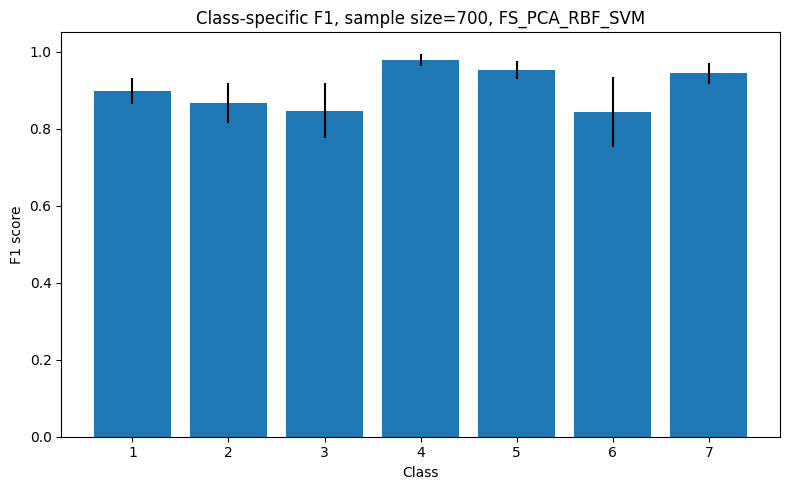

Saved: q1a_results\plot_class_f1_FS_PCA_RBF_SVM_n700.png


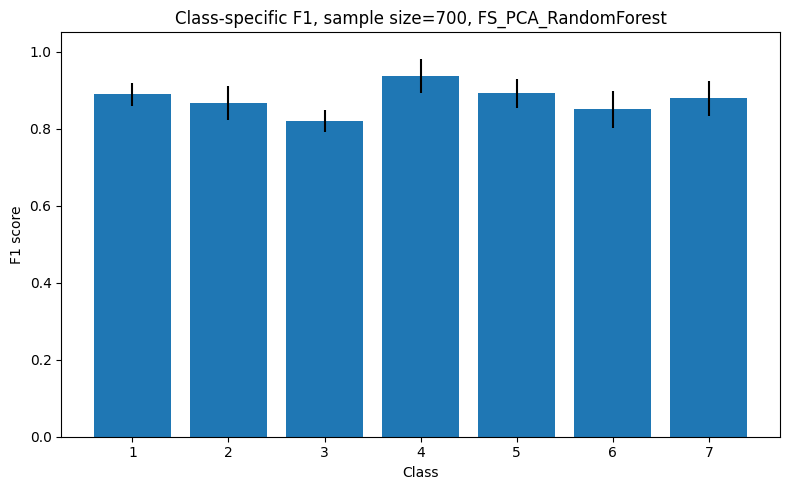

Saved: q1a_results\plot_class_f1_FS_PCA_RandomForest_n700.png


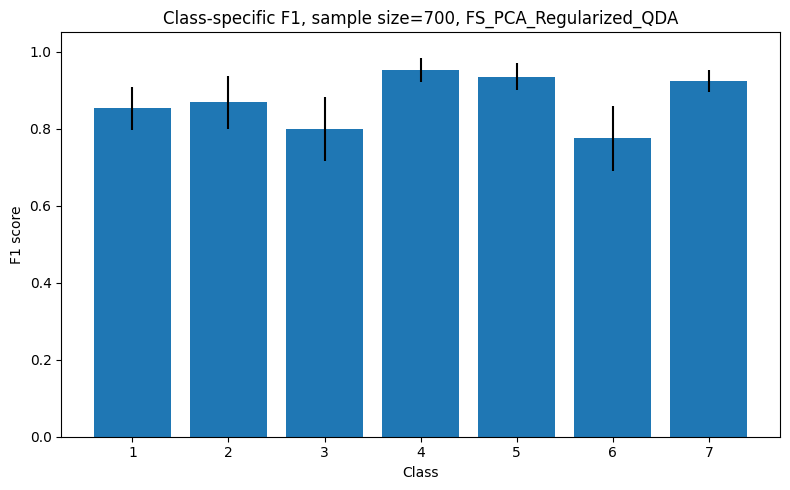

Saved: q1a_results\plot_class_f1_FS_PCA_Regularized_QDA_n700.png


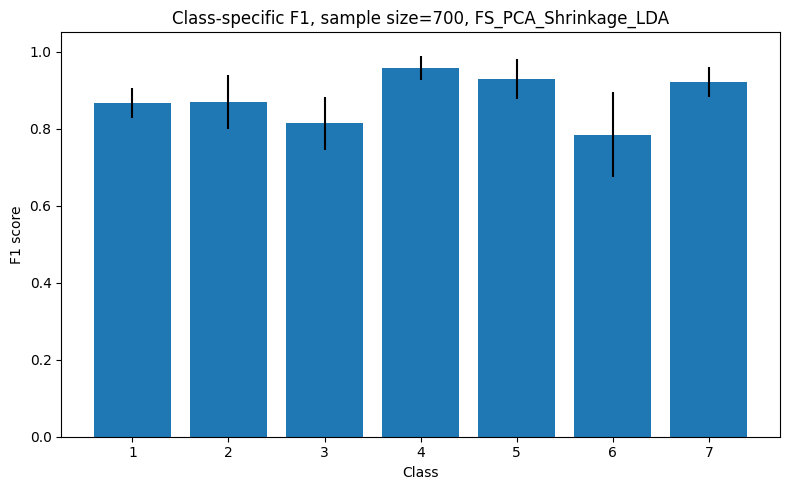

Saved: q1a_results\plot_class_f1_FS_PCA_Shrinkage_LDA_n700.png


In [49]:

# ============================================================
# 14. Plot: class-specific F1 for largest sample size
# ============================================================

largest_sample_size = max(SAMPLE_SIZES)

class_largest = class_summary[
    class_summary["sample_size"] == largest_sample_size
]

for model_name in class_largest["model"].unique():

    tmp = class_largest[class_largest["model"] == model_name]

    plt.figure(figsize=(8, 5))
    plt.bar(tmp["class"].astype(str), tmp["f1_mean"], yerr=tmp["f1_std"])

    plt.xlabel("Class")
    plt.ylabel("F1 score")
    plt.title(f"Class-specific F1, sample size={largest_sample_size}, {model_name}")
    plt.ylim(0, 1.05)
    plt.tight_layout()

    fig_path = os.path.join(
        OUTPUT_DIR,
        f"plot_class_f1_{model_name}_n{largest_sample_size}.png"
    )

    plt.savefig(fig_path, dpi=300)
    plt.show()

    print("Saved:", fig_path)


In [50]:

# ============================================================
# 15. Find best model
# ============================================================

model_ranking = results_df.groupby("model").agg(
    accuracy_mean=("accuracy", "mean"),
    macro_f1_mean=("macro_f1", "mean"),
    accuracy_std=("accuracy", "std"),
    macro_f1_std=("macro_f1", "std")
).reset_index()

model_ranking = model_ranking.sort_values(
    by="macro_f1_mean",
    ascending=False
)

model_ranking_path = os.path.join(OUTPUT_DIR, "q1a_model_ranking.csv")
model_ranking.to_csv(model_ranking_path, index=False)

print("\nModel ranking:")
print(model_ranking)

print("\nSaved:")
print(model_ranking_path)

best_model_name = model_ranking.iloc[0]["model"]
print("\nBest model based on average macro F1:", best_model_name)



Model ranking:
                    model  accuracy_mean  macro_f1_mean  accuracy_std  \
6    FS_PCA_Shrinkage_LDA       0.818254       0.821229      0.060875   
3          FS_PCA_RBF_SVM       0.804365       0.806065      0.107548   
4     FS_PCA_RandomForest       0.792460       0.793713      0.079952   
2       FS_PCA_Linear_SVM       0.773016       0.776965      0.097407   
1      FS_PCA_L2_Logistic       0.764286       0.767106      0.084100   
0      FS_PCA_L1_Logistic       0.764286       0.765097      0.101494   
5  FS_PCA_Regularized_QDA       0.748413       0.753839      0.137081   

   macro_f1_std  
6      0.058450  
3      0.106043  
4      0.077961  
2      0.089545  
1      0.080519  
0      0.099715  
5      0.130743  

Saved:
q1a_results\q1a_model_ranking.csv

Best model based on average macro F1: FS_PCA_Shrinkage_LDA


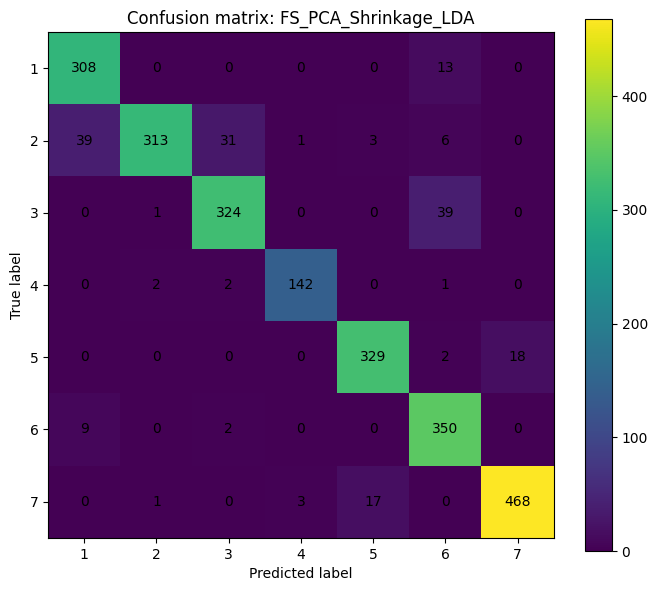

Saved: q1a_results\confusion_matrix_best_model_FS_PCA_Shrinkage_LDA.png


In [51]:

# ============================================================
# 16. Refit best model on a large train/test split and plot confusion matrix
# ============================================================

X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_TR,
    y_TR,
    test_size=TEST_SIZE,
    stratify=y_TR,
    random_state=RANDOM_STATE
)

best_pipeline = clone(pipelines[best_model_name])
best_param_grid = adjust_param_grid_for_sample_size(
    param_grids[best_model_name],
    X_train_full
)

best_model, best_params, best_cv_score = fit_with_inner_cv(
    best_pipeline,
    best_param_grid,
    X_train_full,
    y_train_full
)

y_pred_full = best_model.predict(X_test_full)

cm = confusion_matrix(y_test_full, y_pred_full)
classes = sorted(y_TR.unique())

plt.figure(figsize=(7, 6))
plt.imshow(cm)
plt.colorbar()

plt.xticks(np.arange(len(classes)), classes)
plt.yticks(np.arange(len(classes)), classes)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title(f"Confusion matrix: {best_model_name}")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.tight_layout()

fig_path = os.path.join(OUTPUT_DIR, f"confusion_matrix_best_model_{best_model_name}.png")
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved:", fig_path)


In [52]:

# ============================================================
# 17. Inspect selected features in best model
# ============================================================

selected_features = extract_selected_feature_indices(best_model)
n_selected = len(selected_features)

print("\nBest model selected feature count:", n_selected)
print("First 30 selected feature indices:")
print(selected_features[:30])

selected_feature_path = os.path.join(
    OUTPUT_DIR,
    f"selected_features_best_model_{best_model_name}.csv"
)

pd.DataFrame({
    "selected_feature_index": selected_features
}).to_csv(selected_feature_path, index=False)

print("Saved:", selected_feature_path)



Best model selected feature count: 50
First 30 selected feature indices:
[6, 9, 18, 31, 53, 86, 88, 112, 129, 132, 135, 145, 152, 210, 241, 244, 250, 269, 271, 277, 297, 318, 355, 424, 432, 456, 459, 478, 502, 505]
Saved: q1a_results\selected_features_best_model_FS_PCA_Shrinkage_LDA.csv


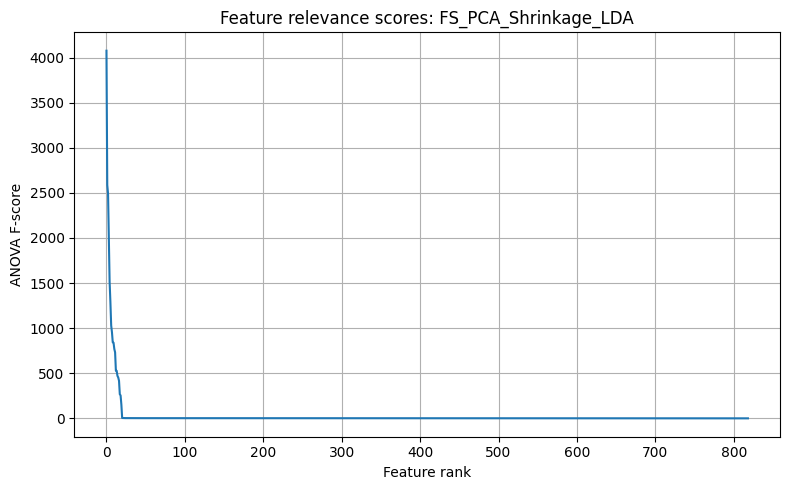

Saved: q1a_results\feature_scores_best_model_FS_PCA_Shrinkage_LDA.png


In [53]:

# ============================================================
# 18. Optional: feature score plot from SelectKBest
# ============================================================

if "select" in best_model.named_steps:

    selector = best_model.named_steps["select"]

    scores = selector.scores_
    scores = np.nan_to_num(scores, nan=0.0)

    sorted_scores = np.sort(scores)[::-1]

    plt.figure(figsize=(8, 5))
    plt.plot(sorted_scores)
    plt.xlabel("Feature rank")
    plt.ylabel("ANOVA F-score")
    plt.title(f"Feature relevance scores: {best_model_name}")
    plt.grid(True)
    plt.tight_layout()

    fig_path = os.path.join(
        OUTPUT_DIR,
        f"feature_scores_best_model_{best_model_name}.png"
    )

    plt.savefig(fig_path, dpi=300)
    plt.show()

    print("Saved:", fig_path)
